# Fase 1 — Carregamento e Análise Exploratória de Imagens (EDA)

Nesta etapa será realizado o carregamento do dataset MNIST e uma análise inicial da estrutura dos dados.

Serão avaliados:
- dimensionalidade das matrizes X e y;
- distribuição das classes de 0 a 9;
- visualização de exemplos das imagens;
- representação das imagens 28 x 28 como 784 features;
- escala de intensidade dos pixels.


In [11]:
# Importação das bibliotecas necessárias.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Importa a função fetch_openml do módulo datasets da biblioteca scikit-learn.
# Essa função será utilizada para carregar o dataset MNIST disponibilizado no OpenML.

from sklearn.datasets import fetch_openml


In [ ]:
# Carregar o dataset MNIST a partir do OpenML utilizando a função fetch_openml.

print("Baixando o dataset MNIST...")

mnist = fetch_openml(
    'mnist_784',
    version=1,
    as_frame=False,
    parser='auto'
)

X = mnist.data.astype(np.float32)
y = mnist.target.astype(np.uint8)

print(f'Formato de X: {X.shape}')
print(f'Formato de y: {y.shape}')
print(f'Faixa original dos pixels: {X.min():.0f} a {X.max():.0f}')

print("Dataset MNIST baixado com sucesso!")

In [30]:
# Identifica as classes únicas em y e conta quantas vezes cada uma aparece.
classes, contagens = np.unique(y, return_counts=True)

# Organiza os resultados em um DataFrame do Pandas.
df_distribuicao = pd.DataFrame({
    'digito': classes,
    'quantidade': contagens
})

# Calcula o percentual de cada classe em relação ao total de imagens.
df_distribuicao['percentual'] = (
    df_distribuicao['quantidade'] / len(y) * 100
).round(2)

# Define a coluna "digito" como índice.
df_distribuicao = df_distribuicao.set_index('digito')

df_distribuicao

,quantidade,percentual
digito,,
0,6903,9.86
1,7877,11.25
2,6990,9.99
3,7141,10.20
4,6824,9.75
5,6313,9.02
6,6876,9.82
7,7293,10.42
8,6825,9.75


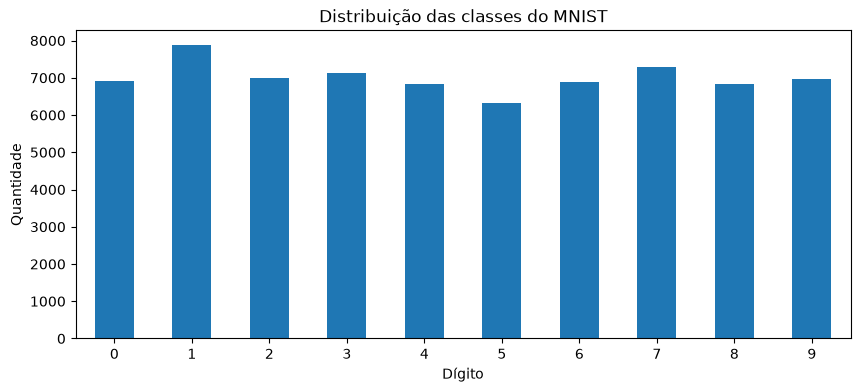

In [31]:
# Gera um gráfico de barras para facilitar a comparação visual das classes.
ax = df_distribuicao['quantidade'].plot.bar(figsize=(10, 4))

# Adiciona título e nomes aos eixos do gráfico.
ax.set(
    title='Distribuição das classes do MNIST',
    xlabel='Dígito',
    ylabel='Quantidade'
)

# Mantém os rótulos de 0 a 9 na horizontal.
ax.tick_params(axis='x', rotation=0)

# Exibe o gráfico.
plt.show()

### Análise da distribuição das classes

As quantidades de imagens entre os dígitos de 0 a 9 são relativamente próximas. Os percentuais ficam próximos de 10% por classe, indicando que o dataset MNIST apresenta uma distribuição relativamente balanceada entre as classes.

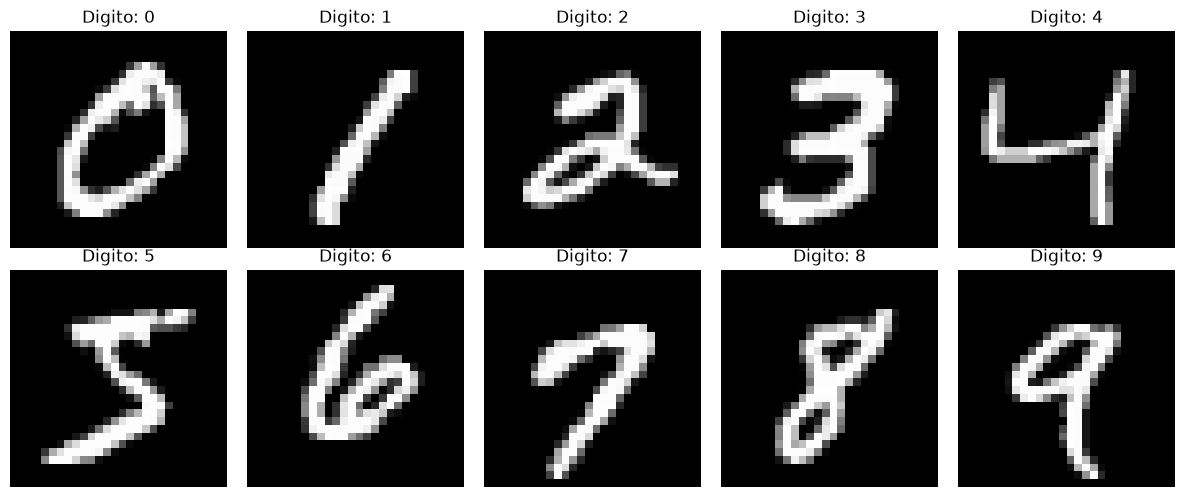

In [22]:
# Cria uma figura com 2 linhas e 5 colunas.
fig, axes = plt.subplots(2,5, figsize=(12,5))

# Percorre os dígitos de 0 a 9.

for digito in range(10):

     # Encontra a posição da primeira ocorrência desse dígito em y.
     indice = np.where(y == digito)[0][0]

     # Recupera a imagem correspondente e reorganiza para 28 x 28.
     imagem = X[indice].reshape(28, 28)

     # Define em qual posição da grade a imagem será exibida.
     eixo = axes.flat[digito]

     # Exibe a imagem em escala de cinza.
     eixo.imshow(imagem, cmap= 'gray')

     # Exibe o rótulo verdadeiro como título.
     eixo.set_title(f'Digito: {y[indice]}')

     # Remove os eixos para facilitar a visualização.
     eixo.axis('off')


# Ajusta o espaçamento entre as imagens.
plt.tight_layout()

# Exibe a grade completa.
plt.show()






### Interpretação da estrutura dos dados

O dataset MNIST possui 70.000 imagens de dígitos manuscritos. Cada imagem possui dimensão de 28 x 28 pixels, totalizando 784 pixels por imagem.

Para os modelos de Machine Learning, cada imagem é representada de forma vetorial, ou seja, os 784 pixels são organizados como 784 características (features) de entrada.

Os valores dos pixels variam de 0 a 255 e representam a intensidade de cada pixel na imagem em escala de cinza. Dessa forma, o modelo utiliza os valores numéricos dos pixels para aprender padrões que diferenciam os dígitos de 0 a 9.

# Fase 2 — Pipeline de Pré-processamento e Divisão dos Dados

Nesta etapa será realizado o pré-processamento dos dados do MNIST e a divisão do conjunto em subconjuntos de treino, validação e teste.

Serão avaliados:
- divisão dos dados em treino, validação e teste;
- uso de estratificação para preservar a proporção das classes;
- normalização dos valores dos pixels;
- verificação das dimensões dos subconjuntos gerados;
- justificativa da importância do pré-processamento para os modelos de Machine Learning.

In [36]:
# Importa a função utilizada para dividir os dados em subconjuntos.
from sklearn.model_selection import train_test_split

# Divide o conjunto completo em treino/validação e teste.
# 20% dos dados são reservados para o teste final.
X_treino_validacao, X_teste, y_treino_validacao, y_teste = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

In [37]:
# Divide o conjunto de treino/validação em treino e validação.
# 12,5% dos 80% restantes correspondem a 10% do dataset original.
X_treino, X_validacao, y_treino, y_validacao = train_test_split(
    X_treino_validacao,
    y_treino_validacao,
    test_size=0.125,
    stratify=y_treino_validacao,
    random_state=42
)

In [39]:
# Cria uma tabela para conferir a quantidade e o percentual de dados em cada subconjunto.
df_divisao = pd.DataFrame({
    'conjunto': ['Treino', 'Validação', 'Teste'],
    'quantidade': [
        len(X_treino),
        len(X_validacao),
        len(X_teste)
    ]
})

# Calcula o percentual de cada conjunto em relação ao total.
df_divisao['percentual'] = (
    df_divisao['quantidade'] / len(X) *100
).round(2)

# Define a coluna "conjunto" como índice.
df_divisao = df_divisao.set_index('conjunto')

# Exibe a tabela.
df_divisao

,quantidade,percentual
conjunto,,
Treino,49000,70.0
Validação,7000,10.0
Teste,14000,20.0


In [40]:
# Normaliza os valores dos pixels para o intervalo entre 0.0 e 1.0.
X_treino = X_treino / 255.0
X_validacao = X_validacao /255.0
X_teste = X_teste / 255.0

In [ ]:
# Cria uma tabela para verificar os valores mínimo e máximodos pixels após a normalização.

df_normalizacao = pd.DataFrame({
    'conjunto': ['Treino', 'Validação', 'Teste'],
    'valor_minimo': [
        X_treino.min(),
        X_validacao.min(),
        X_teste.min()
    ],
    'valor_maximo': [
        X_treino.max(),
        X_validacao.max(),
        X_teste.max()
    ]
})

# Define a coluna "conjunto" como índice.
df_normalizacao = df_normalizacao.set_index('conjunto')

# Exibe a tabela.
df_normalizacao

,valor_minimo,valor_maximo
conjunto,,
Treino,0.0,1.0
Validação,0.0,1.0
Teste,0.0,1.0


### Normalização dos dados

Os valores dos pixels originalmente variam entre 0 e 255. Nesta etapa, os dados foram normalizados para o intervalo entre 0.0 e 1.0 por meio da divisão dos valores por 255.0.

A normalização mantém a relação entre as intensidades dos pixels, mas reduz sua escala numérica. Esse pré-processamento é importante principalmente para modelos que utilizam cálculos de distância ou processos de otimização, pois facilita o tratamento dos valores durante o treinamento.